In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.nflow import nflowDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.tangent_space_svd import TangentSpacel2SVD
from src.manifolds.euclidean.pullback import PullbackEuclidean
from src.manifolds.isometrized_euclidean.exact import l2IsometrizedExactEuclidean

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

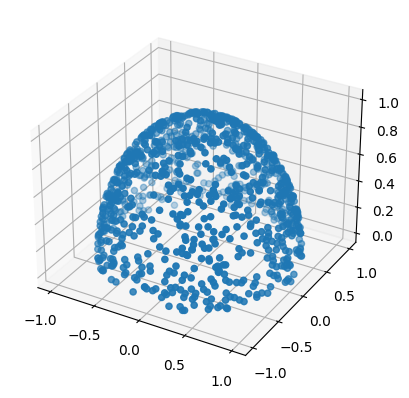

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000

data_train = uniform_sphere_sampling(3, num_samples)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for _ in range(n_flows):
        transforms_list.append(transforms.MaskedAffineAutoregressiveTransform(features=dim, hidden_features=16))
        transforms_list.append(transforms.RandomPermutation(features=dim))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [4]:
# Initialize the model
dim = 3
n_flows = 4
model = create_flow_model(dim, n_flows).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, l1_weight):
    for epoch in range(n_epochs):
        for batch_idx, x in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = -model.log_prob(x).mean()

            # Compute J_inv
            y, _ = model._transform(x)
            J_inv = torch.autograd.functional.jacobian(lambda z: model._transform.inverse(z)[0].sum(0), y)
            
            # Compute J_inv^T J_inv
            J_inv_T_J_inv = torch.einsum("kNi,kNj->Nij", J_inv, J_inv)
            
            # L1 regularization on off-diagonal elements
            off_diag_mask = ~torch.eye(dim, dtype=bool).unsqueeze(0).expand_as(J_inv_T_J_inv)
            l1_reg = l1_weight * dim * torch.mean(torch.abs(J_inv_T_J_inv[off_diag_mask]))
            
            # Add regularization to loss
            loss += l1_reg
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Log Likelihood: {loss.item() - l1_reg.item():.4f}")

In [6]:
# Train the model
n_epochs = 100
l1_weight = 0.01
train(model, train_loader, optimizer, n_epochs, l1_weight)

Epoch 1/100, Loss: 6.4019, Log Likelihood: 6.3350
Epoch 2/100, Loss: 5.8096, Log Likelihood: 5.7688
Epoch 3/100, Loss: 5.2044, Log Likelihood: 5.1804
Epoch 4/100, Loss: 4.5838, Log Likelihood: 4.5705
Epoch 5/100, Loss: 3.9795, Log Likelihood: 3.9720
Epoch 6/100, Loss: 3.4871, Log Likelihood: 3.4827
Epoch 7/100, Loss: 3.0991, Log Likelihood: 3.0959
Epoch 8/100, Loss: 2.6912, Log Likelihood: 2.6884
Epoch 9/100, Loss: 2.3328, Log Likelihood: 2.3303
Epoch 10/100, Loss: 2.0893, Log Likelihood: 2.0872
Epoch 11/100, Loss: 1.9863, Log Likelihood: 1.9847
Epoch 12/100, Loss: 1.9307, Log Likelihood: 1.9293
Epoch 13/100, Loss: 1.8787, Log Likelihood: 1.8772
Epoch 14/100, Loss: 1.8335, Log Likelihood: 1.8318
Epoch 15/100, Loss: 1.7961, Log Likelihood: 1.7943
Epoch 16/100, Loss: 1.7710, Log Likelihood: 1.7690
Epoch 17/100, Loss: 1.7498, Log Likelihood: 1.7476
Epoch 18/100, Loss: 1.7268, Log Likelihood: 1.7244
Epoch 19/100, Loss: 1.7047, Log Likelihood: 1.7021
Epoch 20/100, Loss: 1.6823, Log Likeliho

In [7]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

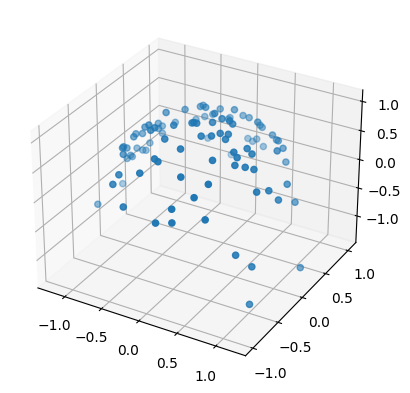

In [8]:
# Visualize generated samples
samples = generate_samples(model, 100)

ax = plt.axes(projection='3d')
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

### Evaluating Geometry ###

In [9]:
# Construct diffeomorphism
phi = nflowDiffeomorphism(3, model)

# Construct pullback manifold
manifold = PullbackEuclidean(phi)

# Construct isometrized pullback manifold
iso_manifold = l2IsometrizedExactEuclidean(manifold)

In [10]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [11]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()
iso_geodesic_x0_x1 = iso_manifold.geodesic(x0,x1,t).detach().cpu().numpy()

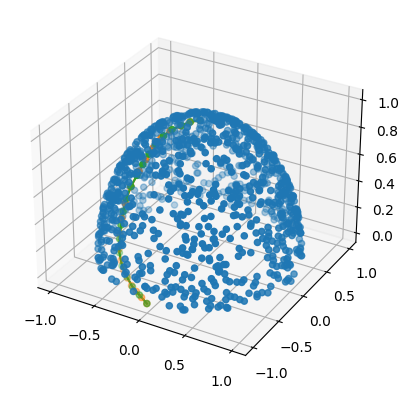

In [12]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.plot(iso_geodesic_x0_x1[:,0], iso_geodesic_x0_x1[:,1], iso_geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
ax.scatter(iso_geodesic_x0_x1[:,0], iso_geodesic_x0_x1[:,1], iso_geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

In [13]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
iso_bary = iso_manifold.barycentre(data_train.to(device))

iteration 1 | rel_error = 0.9856505990028381
iteration 2 | rel_error = 0.851107120513916
iteration 3 | rel_error = 0.6583933234214783
iteration 4 | rel_error = 0.4905960261821747
iteration 5 | rel_error = 0.3130854368209839
iteration 6 | rel_error = 0.21079544723033905
iteration 7 | rel_error = 0.1888120174407959
iteration 8 | rel_error = 0.14815554022789001
iteration 9 | rel_error = 0.10665793716907501
iteration 10 | rel_error = 0.0799010843038559
gradient descent was terminated after reaching a relative error 0.0799010843038559 in 10 iterations


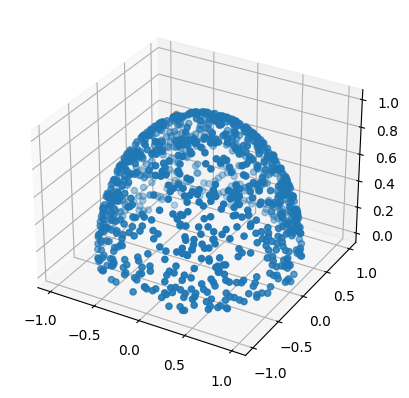

In [14]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(iso_bary.detach().cpu().numpy()[0], iso_bary.detach().cpu().numpy()[1], iso_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

In [15]:
# construct curvature corrected l2-pga solver
l2_pga_solver_bary = TangentSpacel2SVD(data_train.to(device), manifold, bary)
iso_l2_pga_solver_bary = TangentSpacel2SVD(data_train.to(device), iso_manifold, bary)

l2_pga_solver_iso_bary = TangentSpacel2SVD(data_train.to(device), manifold, iso_bary)
iso_l2_pga_solver_iso_bary = TangentSpacel2SVD(data_train.to(device), iso_manifold, iso_bary)

In [16]:
# compute low rank approximations
l2_pga_solver_bary.solve(2) # compute rank 2 approximation
iso_l2_pga_solver_bary.solve(2) # compute rank 2 approximation

l2_pga_solver_iso_bary.solve(2) # compute rank 2 approximation
iso_l2_pga_solver_iso_bary.solve(2) # compute rank 2 approximation

In [17]:
# compute approximations
approximations_bary = manifold.exp(bary, l2_pga_solver_bary.Xi[2])
iso_approximations_bary = iso_manifold.exp(bary, iso_l2_pga_solver_bary.Xi[2])

approximations_iso_bary = manifold.exp(iso_bary, l2_pga_solver_iso_bary.Xi[2])
iso_approximations_iso_bary = iso_manifold.exp(iso_bary, iso_l2_pga_solver_iso_bary.Xi[2])

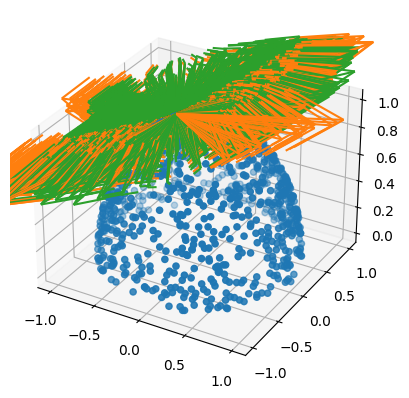

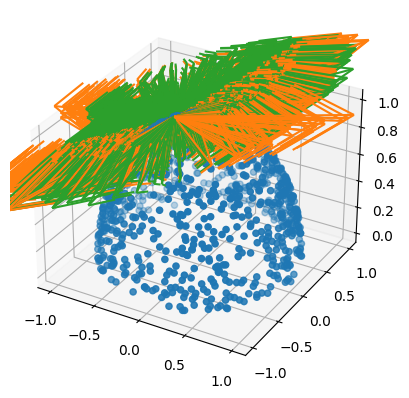

In [18]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver_bary.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(iso_l2_pga_solver_bary.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             iso_l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 0], iso_l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 1], iso_l2_pga_solver_bary.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(iso_bary.detach().cpu().numpy()[0], iso_bary.detach().cpu().numpy()[1], iso_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver_iso_bary.log_x_data.shape[0]):
    ax.quiver(iso_bary.detach().cpu().numpy()[0], iso_bary.detach().cpu().numpy()[1], iso_bary.detach().cpu().numpy()[2], 
             l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(iso_l2_pga_solver_iso_bary.log_x_data.shape[0]):
    ax.quiver(iso_bary.detach().cpu().numpy()[0], iso_bary.detach().cpu().numpy()[1], iso_bary.detach().cpu().numpy()[2], 
             iso_l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 0], iso_l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 1], iso_l2_pga_solver_iso_bary.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()


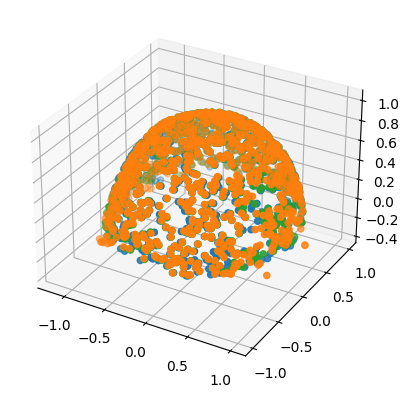

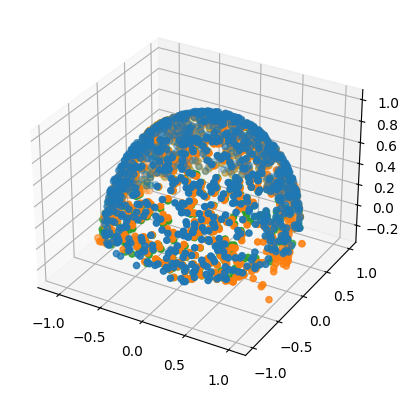

In [19]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations_bary.detach().cpu().numpy()[:,0], approximations_bary.detach().cpu().numpy()[:,1], approximations_bary.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(iso_approximations_bary.detach().cpu().numpy()[:,0], iso_approximations_bary.detach().cpu().numpy()[:,1], iso_approximations_bary.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations_iso_bary.detach().cpu().numpy()[:,0], approximations_iso_bary.detach().cpu().numpy()[:,1], approximations_iso_bary.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(iso_approximations_iso_bary.detach().cpu().numpy()[:,0], iso_approximations_iso_bary.detach().cpu().numpy()[:,1], iso_approximations_iso_bary.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

In [20]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations_bary)**2,0).sum())
print(torch.mean((data_train.to(device) - iso_approximations_bary)**2,0).sum())

print(torch.mean((data_train.to(device) - approximations_iso_bary)**2,0).sum())
print(torch.mean((data_train.to(device) - iso_approximations_iso_bary)**2,0).sum())

tensor(0.0035, grad_fn=<SumBackward0>)
tensor(0.0008)
tensor(0.0055, grad_fn=<SumBackward0>)
tensor(0.0020)
